In [212]:
%load_ext autoreload
%autoreload 2

import numpy as np
import warnings
import time

import pandas as pd
import random

import numpy.ma as ma
from tqdm import tqdm
from src.traffic_sim import *
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [213]:
# Read in the data
# downstream_density = np.load('i24_data/downstream_density_200_14seg.npy').reshape(-1)
# data_inflow = np.load('i24_data/initial_flow_200_14seg.npy').reshape(-1)

downstream_density = np.load('src/sim_params/200m_10_sec/downstream_density.npy').reshape(-1)
data_inflow = np.load('src/sim_params/200m_10_sec/upstream_flow.npy').reshape(-1)

true_density_initial = np.load('/Users/shreyaar/Desktop/PhD/research/MPC/src/sim_params/200m_10_sec/density_10sec_200m_1hr.npy')[0, 1:-1].reshape(-1)
true_velocity_initial = np.load('/Users/shreyaar/Desktop/PhD/research/MPC/src/sim_params/200m_10_sec/velocity_10sec_200m_1hr.npy')[0, 1:-1].reshape(-1)

#downstream_density = np.load('/Users/shreyaar/Desktop/PhD/research/MPC/src/sim_params/200m_10_sec/density_10sec_200m_1hr.npy')[:, 2:3]
print(downstream_density.shape)
print(true_density_initial.shape)
print(true_velocity_initial.shape)
# print(true_density_initial.shape)

(360,)
(30,)
(30,)


In [214]:
from src.sim_params.default import DefaultParams
from src.sim_params.I24_400mParams import I24_400mParams
from src.sim_params.I24_6seg_FD_400mParams import I24_400m_6seg_indivFD_Params
from src.sim_params.I24_14seg_200mParams import I24_200m_14seg_indivFD_Params
from src.sim_params.I24_30seg_200mParams import I24_30seg_200m_indivFD_Params

In [241]:
time_step = 10/3600
time_steps = downstream_density.shape[0]
print("sim_time:", time_step * downstream_density.shape[0] * 60, "minutes")

total_distance = .2 * 30  # 6 segments of 200 m each
L = 0.2
num_segments = 30 #30
# sim_lanes = {i: 5 if i < 4 else 4 for i in range(num_segments)} 
#sim_lanes = {0: 5, 1: 5, 2: 4, 3: 4, 4: 4, 5: 4} 
# sim_lanes = {0: 4, 1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 4, 7: 4, 8: 4, 9: 4, 10: 4, 11: 4, 12: 5, 13:5, 14:4} 
lane_counts = np.load('src/sim_params/200_m_10_s_joint/num_lanes.npy').reshape(-1)
sim_lanes = {i: lane_counts[i] for i in range(num_segments)}
sim_lanes = {i: 4 for i in range(num_segments)}
print("length of highway:", total_distance, "km")
print(sim_lanes)

i24params = I24_30seg_200m_indivFD_Params(joint=True).get_params()

print(data_inflow.shape, lane_counts.shape)

inflow = data_inflow * sim_lanes[0]
# inflow = np.full(data_inflow.shape, 1000 * 4)


sim_time: 60.0 minutes
length of highway: 6.0 km
{0: 4, 1: 4, 2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 4, 11: 4, 12: 4, 13: 4, 14: 4, 15: 4, 16: 4, 17: 4, 18: 4, 19: 4, 20: 4, 21: 4, 22: 4, 23: 4, 24: 4, 25: 4, 26: 4, 27: 4, 28: 4, 29: 4}
(360,) (30,)


In [242]:
# Apply smoothing to the inflow data
def smooth_inflow(inflow, window_size=5):
    return np.convolve(inflow, np.ones(window_size)/window_size, mode='same')
data_inflow = smooth_inflow(data_inflow, window_size=2)
downstream_density = smooth_inflow(downstream_density, window_size=2)

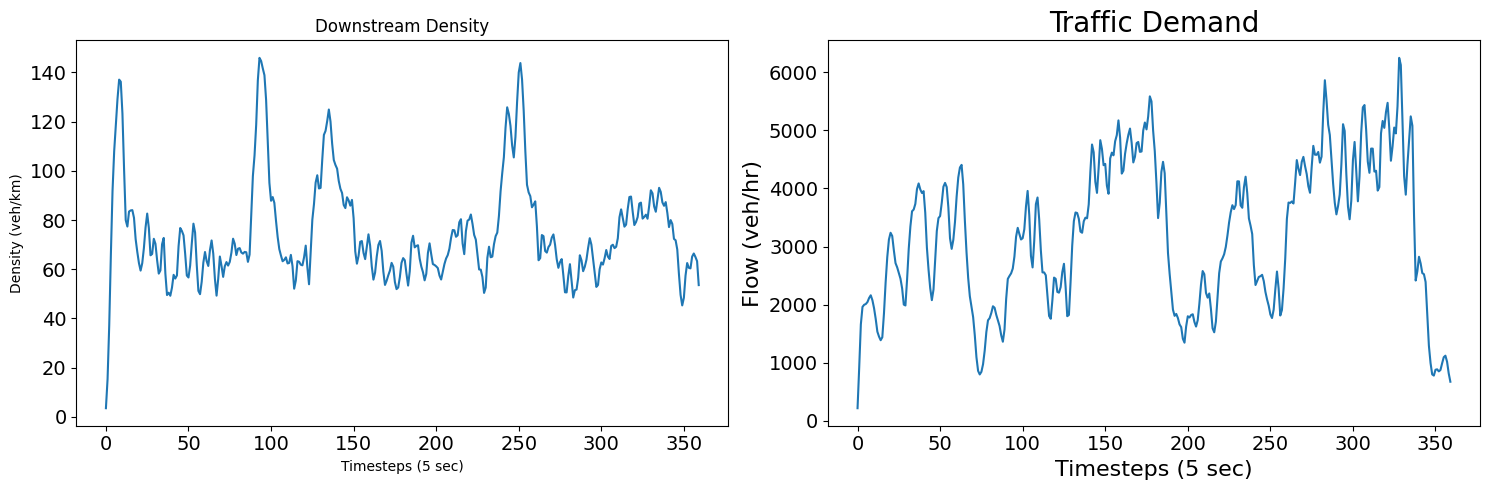

In [243]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(downstream_density)
axs[0].set_title('Downstream Density')
# axs[0].set_xticks(np.arange(0, time_steps+1, 120), np.arange(0, int(time_steps/12)+1, int(120/12)))
axs[0].set_xlabel('Timesteps (5 sec)')
axs[0].set_ylabel('Density (veh/km)')

axs[1].plot(data_inflow)
axs[1].set_title('Traffic Demand', fontsize=20)
# axs[1].set_xticks(np.arange(0, time_steps+1, 120), np.arange(0, int(time_steps/12)+1, int(120/12)))
axs[1].set_xlabel('Timesteps (5 sec)', fontsize=16)
axs[1].set_ylabel('Flow (veh/hr)', fontsize=16)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

In [244]:
#{i: 4 if i < int(2*num_segments/3) else 2 for i in range(num_segments)}
const_vsl = np.array([np.full(num_segments, max(i24params['v_free'])) for i in range(time_steps)])
# p, v, queue, tts = metanet_sim_params(time_step, L, 
#                                       (np.array([inflow[0]/(i24params['v_free'] * sim_lanes[i]) for i in range(num_segments)]), np.full(num_segments, i24params['v_free']), inflow[0], 0), 
#                                     const_vsl, inflow, downstream_density, params=i24params, plotting=True, real_data=True, lanes=sim_lanes)

# print(v.shape)

print(num_segments, time_steps)
p, v, queue, tts = metanet_sim_params(time_step, L, 
                                      (true_density_initial, true_velocity_initial, data_inflow[0], 0), 
                                    const_vsl, data_inflow, downstream_density, params=i24params, plotting=True, real_data=True, lanes=sim_lanes)

print("Total travel time:", tts)
print(p.shape, v.shape)


30 360
Total travel time: 1022.6070642176602
(361, 30) (361, 30)


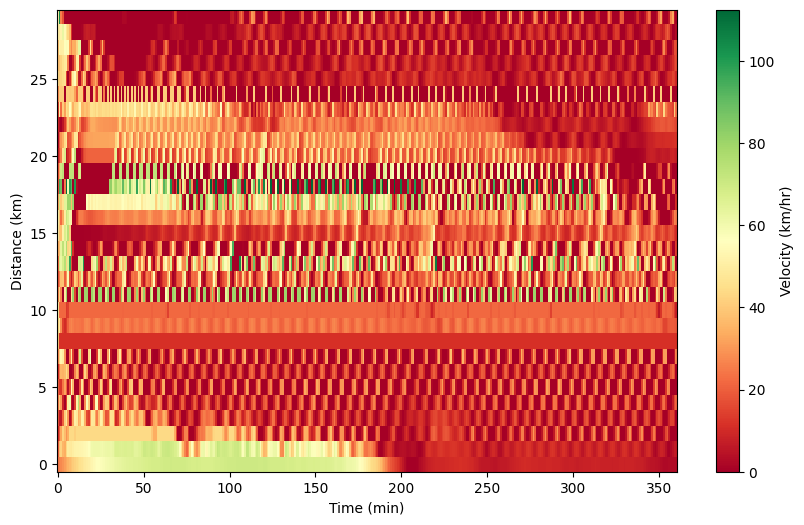

In [245]:
plt.figure(figsize=(10, 6))

plt.imshow(v.T, cmap='RdYlGn', aspect='auto', interpolation='none')
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
# set color bar limits
# plt.clim(0, 120)
# plt.title(f'No Control: {np.round(tts, 2)} veh-hr, Total Delay: {np.round(tts - ff_ttt, 2)} veh-hr')

plt.show()

In [246]:
gt = np.load('/Users/shreyaar/Desktop/PhD/research/MPC/src/sim_params/200m_10_sec/velocity_10sec_200m_1hr.npy')[:, 1:-1]
gt_density = np.load('/Users/shreyaar/Desktop/PhD/research/MPC/src/sim_params/200m_10_sec/density_10sec_200m_1hr.npy')[:, 1:-1]

print(gt.shape)
gt_flow = gt * gt_density

vel = v[:-1, :]
density = p[:-1, :]
flow = vel * density

mape = np.mean(np.abs((gt - vel) / gt) * 100)
p_mape = np.mean(np.abs((gt_density - density) / gt_density) * 100)
q_mape = np.mean(np.abs((gt_flow - flow) / gt_flow) * 100)
print("Density MAPE:", np.round(p_mape, 2), "%")
print("Velocity MAPE:", np.round(mape, 2), "%")
print("Flow MAPE:", np.round(q_mape, 2), "%")

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
""
rmse_value = rmse(gt, vel)
p_rmse_value = rmse(gt_density, density)
q_rmse = rmse(gt_flow, flow)
print("Density RMSE:", np.round(p_rmse_value, 2))
print("Velocity RMSE:", rmse_value)
print("Flow RMSE:", np.round(q_rmse, 2))

(360, 30)
Density MAPE: 137.84 %
Velocity MAPE: 95.17 %
Flow MAPE: 80.89 %
Density RMSE: 38.01
Velocity RMSE: 41.094402674516054
Flow RMSE: 816.58


In [247]:
# Travel time of gt
gt_tt = time_step * (sum([np.sum(gt_density[:, i]) * sim_lanes[i] * L for i in range(num_segments)]))
metanet_tt = time_step * (sum([np.sum(density[:, i]) * sim_lanes[i] * L for i in range(num_segments)]))
print("Ground Truth Travel Time:", np.round(gt_tt, 2), "veh-hr")
print("Metanet Travel Time:", np.round(metanet_tt, 2), "veh-hr")

Ground Truth Travel Time: 606.76 veh-hr
Metanet Travel Time: 1018.21 veh-hr


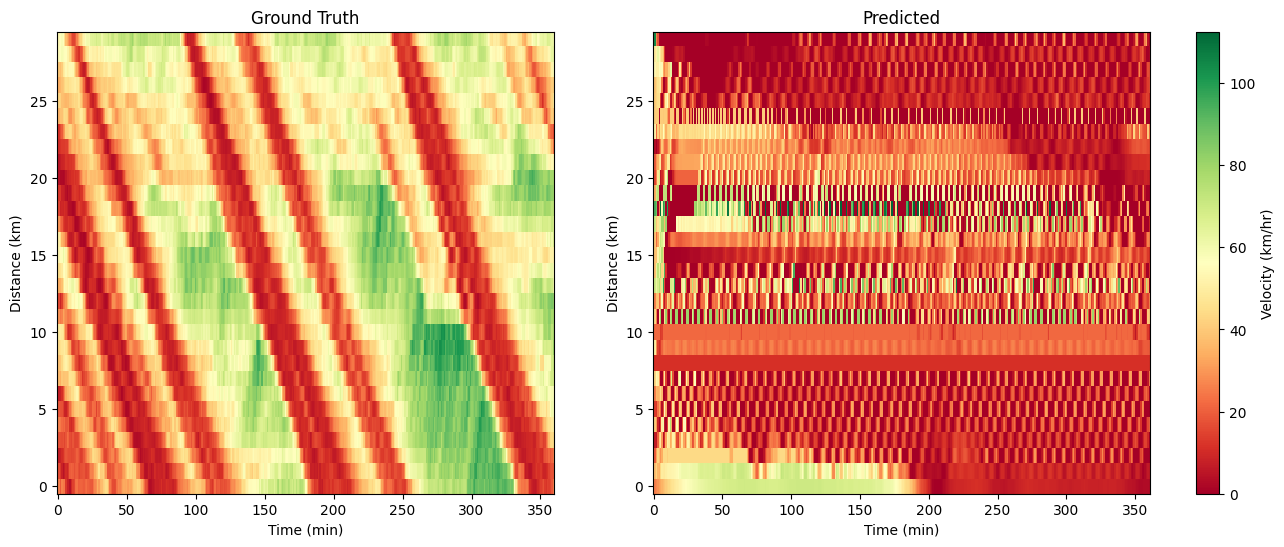

In [248]:
import matplotlib.colors as mcolors

# Normalize the color scale
vmin = min(gt.min(), v.min())
vmax = max(gt.max(), v.max())
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Plot gt
im1 = axs[0].imshow(gt.T, cmap='RdYlGn', aspect='auto', interpolation='none', norm=norm)
axs[0].set_title('Ground Truth')
axs[0].set_xlabel('Time (min)')
axs[0].set_ylabel('Distance (km)')
axs[0].invert_yaxis()
axs[0].xaxis.set_ticks_position('bottom')

# Plot v
im2 = axs[1].imshow(v.T, cmap='RdYlGn', aspect='auto', interpolation='none', norm=norm)
axs[1].set_title('Predicted')
axs[1].set_xlabel('Time (min)')
axs[1].set_ylabel('Distance (km)')
axs[1].invert_yaxis()
axs[1].xaxis.set_ticks_position('bottom')

# Add a single color bar for both plots
cbar = fig.colorbar(im1, ax=axs, orientation='vertical', fraction=0.02, pad=0.04, label='Velocity (km/hr)')

# plt.tight_layout()
plt.show()

In [68]:
pred_horizon = 50  # 30 minutes
control_horizon = 5  # 10 minutes
hold_len = 1

sim_time = downstream_density.shape[0]
time_steps = sim_time + pred_horizon - control_horizon
downstream_density_mpc = np.append(downstream_density, downstream_density[-1])
inflow_mpc = np.append(inflow, inflow[-1])
while len(downstream_density_mpc) <= time_steps + 1:
    downstream_density_mpc = np.append(downstream_density_mpc, downstream_density[-1])
    inflow_mpc = np.append(inflow_mpc, inflow[-1])

print(inflow.shape, downstream_density.shape)
print(downstream_density_mpc.shape, inflow_mpc.shape, time_steps)

(360,) (360,)
(407,) (407,) 405


In [57]:
# Optimize I-24 Scenario
from src.mpc_metanet import mpc_find_vsl

m = num_segments

optimal_vsl = mpc_find_vsl(time_steps, inflow_mpc, downstream_density_mpc, sim_lanes, T=time_step,
                                l=L, num_segments=num_segments, pred_horizon=pred_horizon, control_horizon=control_horizon, 
                                hold_length=hold_len, initialize_vsl=None, init_fixed=None, init_state=(true_density_initial, true_velocity_initial, inflow[0], 0),
                                control_one_segment=None, control_changepoints=None, safety_temporal=None, params=i24params, verbose=True, speed_lb=0)

print(optimal_vsl.shape)

MPC at time step 0
MPC at time step 50
MPC at time step 100
MPC at time step 150
MPC at time step 200
MPC at time step 250
MPC at time step 300
MPC at time step 350
MPC Done
(360, 6)


In [58]:
p_opt, v_opt, queue_opt, tts_opt = metanet_sim_params(time_step, L, (true_density_initial, true_velocity_initial, inflow[0], 0), 
                                    optimal_vsl, inflow_mpc, downstream_density_mpc, i24params,lanes=sim_lanes, real_data=False, plotting=True)

print(f"TTS with VSL Control: {tts_opt} veh-hr")
print(f"TTS without VSL Control: {tts} veh-hr")

TTS with VSL Control: 151.80456089868557 veh-hr
TTS without VSL Control: 190.793698985662 veh-hr


ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (4).

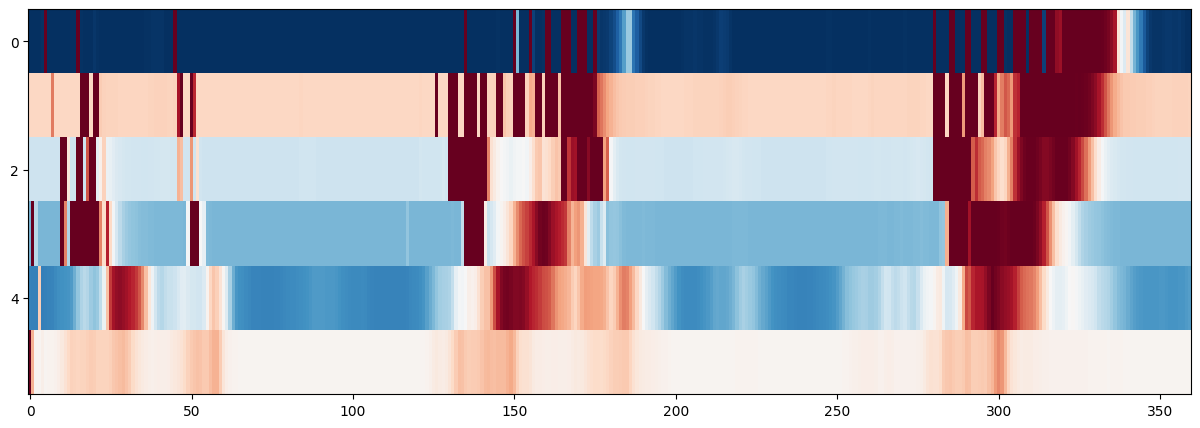

In [59]:
from src.plotting import plot_vsls
plot_vsls(optimal_vsl, time_steps, num_segments, max(i24params['v_free']), T=time_step, l=L)

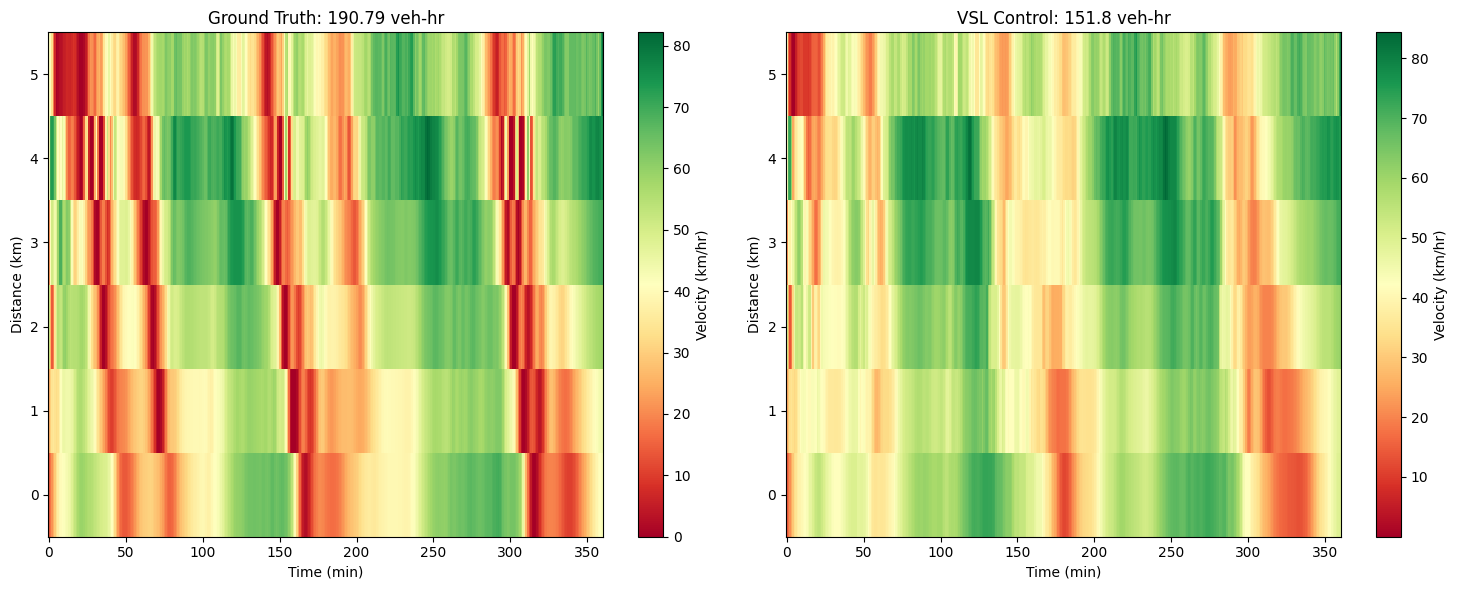

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Plot gt
axs[0].imshow(v.T, cmap='RdYlGn', aspect='auto', interpolation='none')
axs[0].set_title('METANET Ground Truth')
axs[0].set_xlabel('Time (min)')
axs[0].set_ylabel('Distance (km)')
axs[0].invert_yaxis()
axs[0].xaxis.set_ticks_position('bottom')
axs[0].colorbar = fig.colorbar(axs[0].images[0], ax=axs[0], label='Velocity (km/hr)')
axs[0].set_title('Ground Truth: ' + str(np.round(tts, 2)) + ' veh-hr')

# Plot v
axs[1].imshow(v_opt.T, cmap='RdYlGn', aspect='auto', interpolation='none')
axs[1].set_title('METANET with control')
axs[1].set_xlabel('Time (min)')
axs[1].set_ylabel('Distance (km)')
axs[1].invert_yaxis()
axs[1].xaxis.set_ticks_position('bottom')
axs[1].colorbar = fig.colorbar(axs[1].images[0], ax=axs[1], label='Velocity (km/hr)')
axs[1].set_title('VSL Control: ' + str(np.round(tts_opt, 2)) + ' veh-hr')

plt.tight_layout()
plt.show()

In [61]:
from src.generate_demand import get_ff_tt

ff_ttt = get_ff_tt(inflow, time_step, L * num_segments, 120)
delay  = tts - ff_ttt
opt_delay = tts_opt - ff_ttt
cc = (delay - opt_delay) / delay * 100
print(f"Controllable congestion: {cc}%")


Controllable congestion: 29.27280922457055%
